# Task 2 Linear Regression

Import necessary libraries

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso

Step 1: Load and seperate our dataset

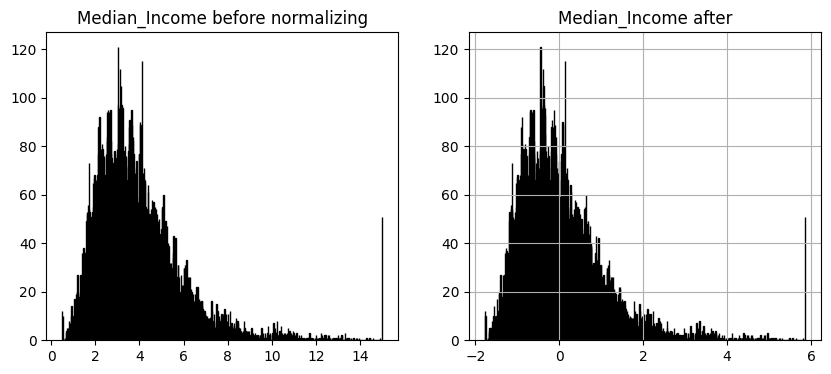

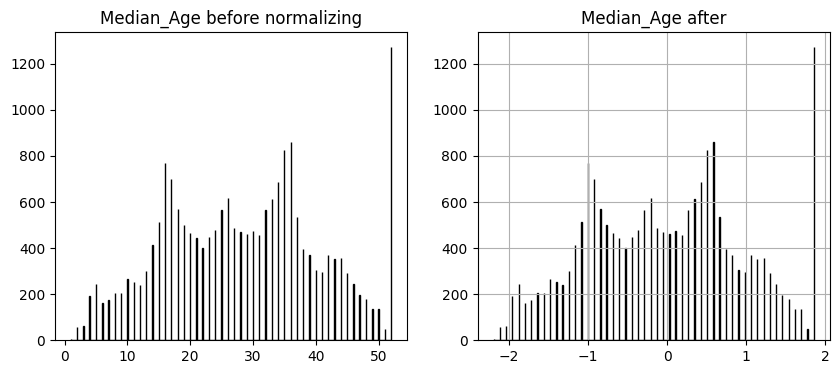

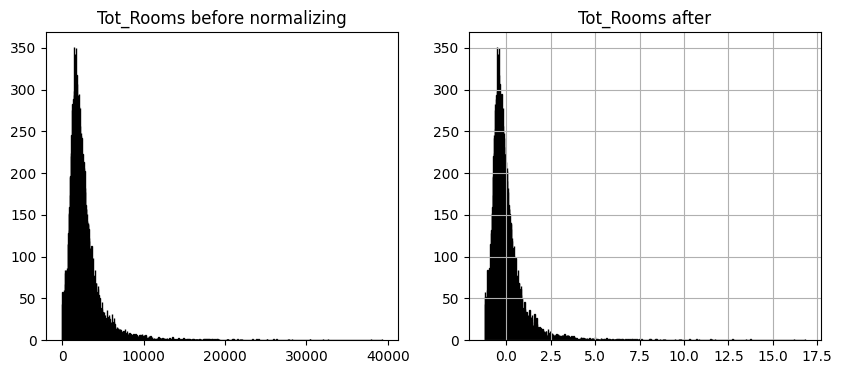

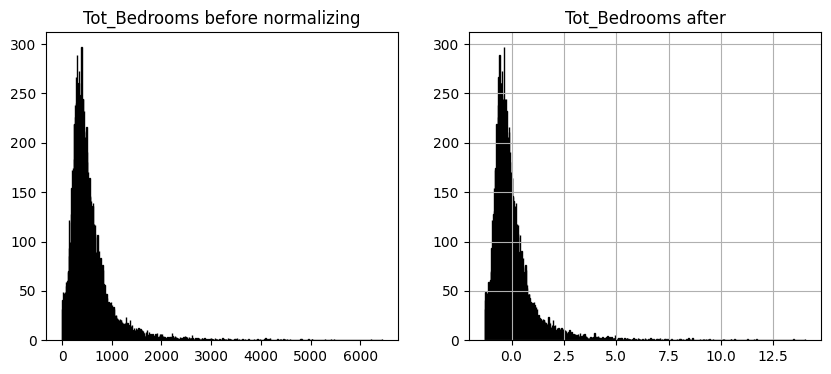

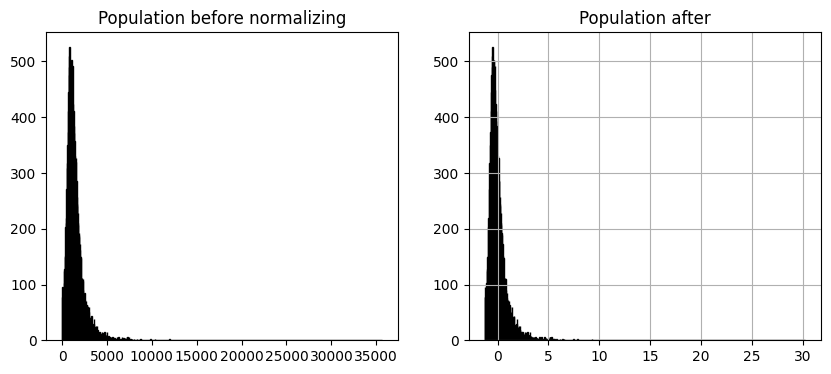

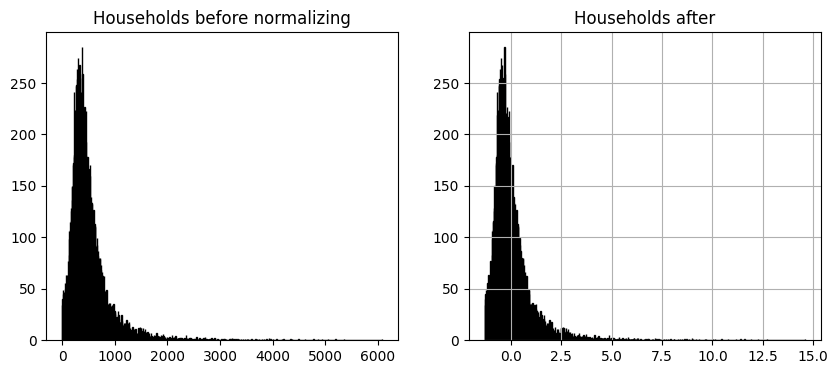

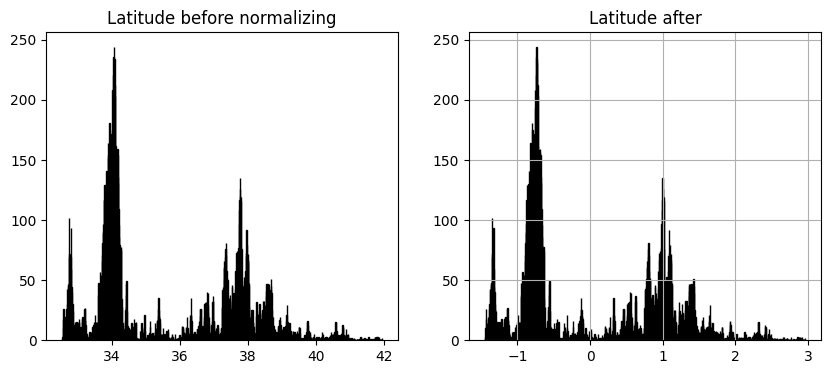

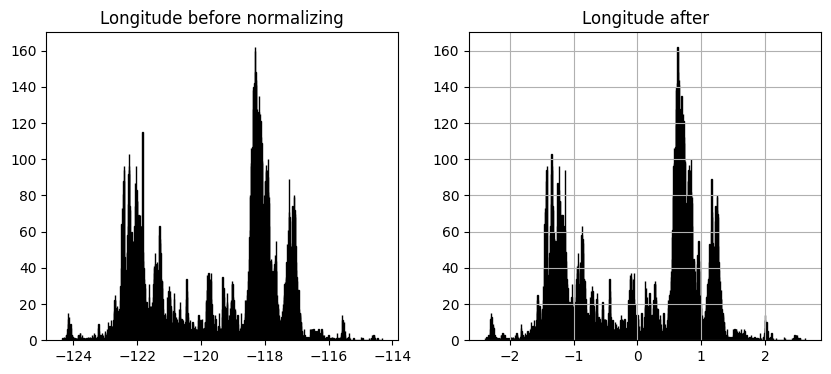

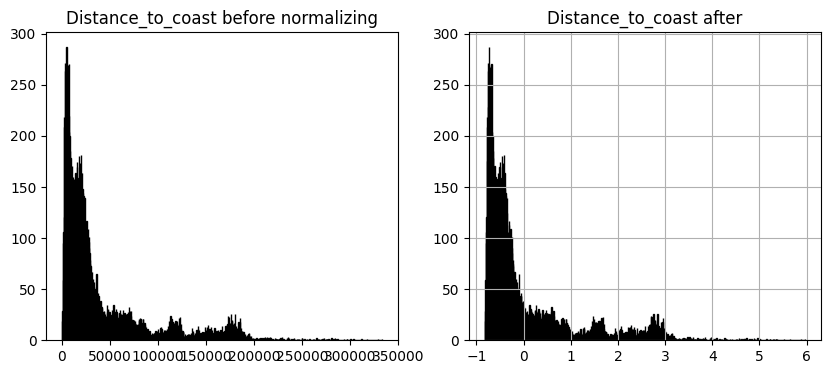

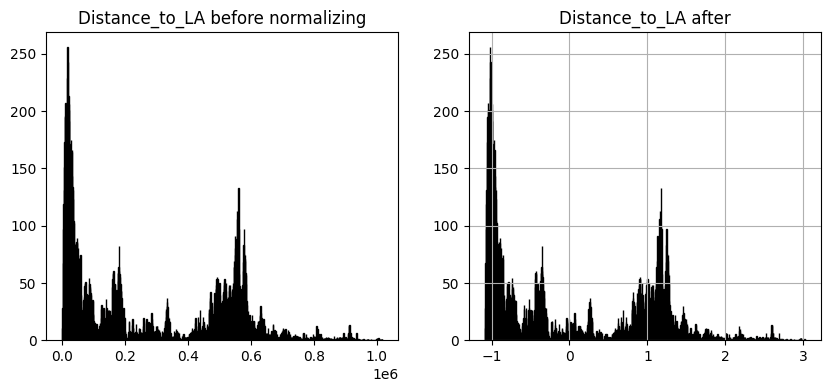

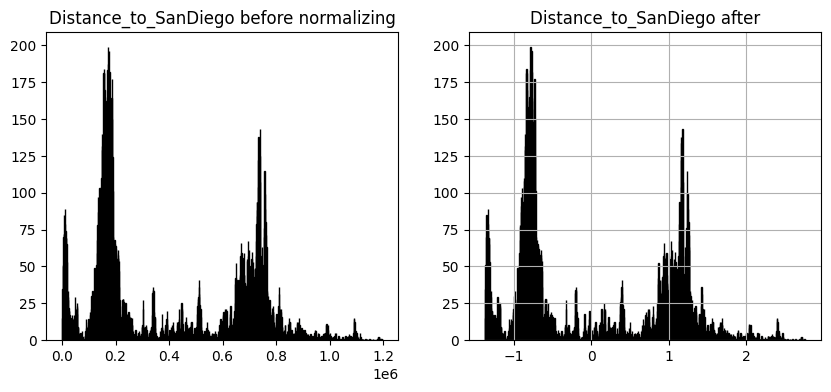

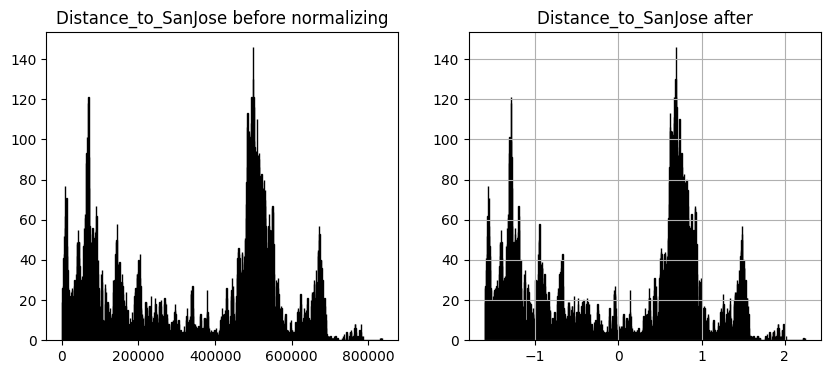

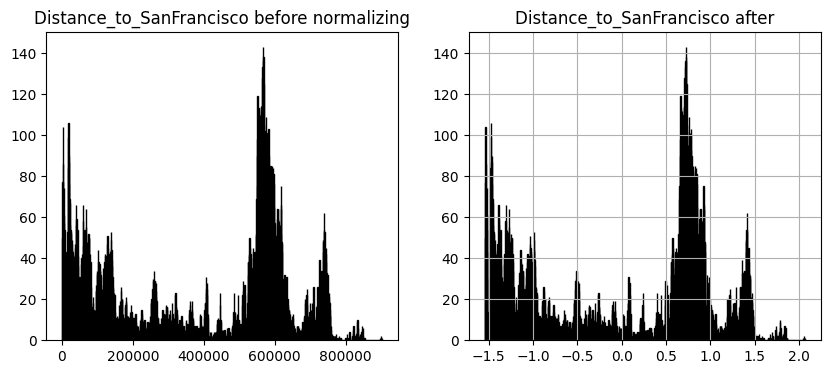

In [ ]:
#read dataset and convert it to pandas dataframe
df=pd.read_csv("California_Houses.csv") 

#seperate targets from features
X = df.drop(columns=['Median_House_Value']) #features dataframe
#converts pandas series to numpy array and reshapes it to a 2D column vector
t = df['Median_House_Value'].values.reshape(-1, 1) #targets vector

# normalize features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#comparing between data before and after normalization
column_names = X.columns.tolist()
for i in range(X_scaled.shape[1]):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].hist(X[column_names[i]], bins=1000, color='skyblue', edgecolor='black')
    axs[0].set_title(column_names[i]+" before normalizing")

    axs[1].hist(X_scaled[:,i], bins=1000, color='skyblue', edgecolor='black')
    axs[1].set_title(column_names[i]+" after")
    plt.grid(True)
    plt.show()

# add column of 1s to make calculations convenient
X_scaled = np.hstack((np.ones((X_scaled.shape[0], 1)), X_scaled))

# split data to 70% for training set, 30% temporarily for validation and test set
X_train, X_temp, t_train, t_temp = train_test_split(X_scaled, t, test_size=0.30, random_state=42)
# split the 30% to 15% for validation set and 15% for test set
X_val, X_test, t_val, t_test = train_test_split(X_temp, t_temp, test_size=0.50, random_state=42)


Step 2: Implementing linear, lasso, and ridge Regression from Scratch using matrix operations(+gradient descent as an alternative optimization approach)

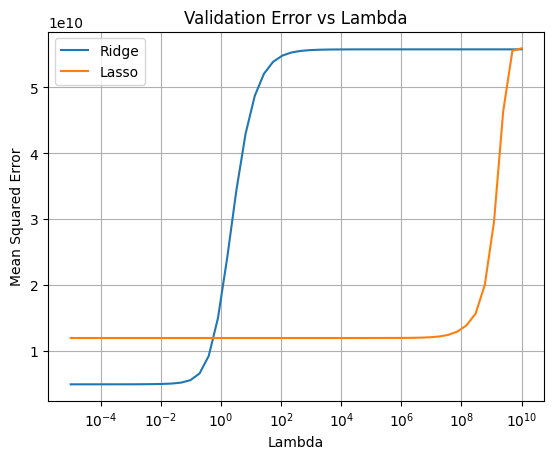

In [57]:
#normal Equation
def normal_eq(X, t):
    return np.linalg.inv(X.T @ X) @ X.T @ t

w_linear = normal_eq(X_train, t_train)

#gradient Descent
def gradient_descent(X, t, alpha=0.001, epochs=1000):
    n, f = X.shape
    w = np.zeros((f, 1))  
    for i in range(epochs):
        w=w-(alpha / n) * (X.T @ (X @ w - t))
    return w

#ridge regression
def ridge_normal_eq(X, t, lam):
    n,f = X.shape
    I = np.identity(f)
    w_ridge=np.linalg.inv(X.T @ X + lam * n * I) @ X.T @ t
    return w_ridge

#lasso regression
#implementing Lasso Regression from scratch using purely matrix operations (like with Ridge) 
#is not possible, so here is an alternative solution using gradient descent
def lasso_gd(X, t, lam, alpha=0.001, epochs=1000):
    n, f = X.shape
    w = np.zeros((f, 1))
    for i in range(epochs):
        grad =  (X.T @ (X @ w - t))
        w = w - (alpha / n) * (grad + lam * np.sign(w))  
    return w

#ploting validation error vs.regularization parameter
#generate an array of 50 values that are logarithmically spaced between 10^(-5) and 10^10:
lambdas = np.logspace(-5, 10, 50)
ridge_errors = []
lasso_errors = []

for lam in lambdas:
    w_ridge = ridge_normal_eq(X_train, t_train, lam)
    w_lasso = lasso_gd(X_train, t_train, lam)
    
    y_ridge = X_val @ w_ridge
    y_lasso = X_val @ w_lasso
    
    ridge_errors.append(mean_squared_error(t_val, y_ridge))
    lasso_errors.append(mean_squared_error(t_val, y_lasso))

plt.plot(lambdas, ridge_errors, label="Ridge")
plt.plot(lambdas, lasso_errors, label="Lasso")
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.title("Validation Error vs Lambda")
plt.grid(True)
plt.show()

Step 3: Using SciKit-Learn

In [ ]:
#linear regression model using SciKit-Learn
linear_model = LinearRegression()
linear_model.fit(X_train, t_train)
linear_y = linear_model.predict(X_test)

#ridge regression model using SciKit-Learn
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, t_train)
ridge_y= ridge_model.predict(X_test)

#lasso regression model using SciKit-Learn
lasso_model = Lasso(alpha=0.1, max_iter=10000)
lasso_model.fit(X_train, t_train)
lasso_y = lasso_model.predict(X_test)


Step 4: Report Mean Square Error and Mean Absolute Errors for all models.

In [53]:
#SciKit linear regression error
linear_mse = mean_squared_error(t_test, linear_y)
linear_mae = mean_absolute_error(t_test, linear_y)

#manual linear regression error
w_linear = normal_eq(X_train, t_train)
y_linearM = X_test @ w_linear
linear_mseM = mean_squared_error(t_test, y_linearM)
linear_maeM = mean_absolute_error(t_test, y_linearM)

#SciKit ridge regression error
ridge_mse = mean_squared_error(t_test, ridge_y)
ridge_mae = mean_absolute_error(t_test, ridge_y)

#manual ridge regression error
w_ridge = ridge_normal_eq(X_train, t_train, 0.0015)
y_ridgeM = X_test @ w_ridge
ridge_mseM = mean_squared_error(t_test, y_ridgeM)
ridge_maeM = mean_absolute_error(t_test, y_ridgeM)
    
#SciKit lasso regression error
lasso_mse = mean_squared_error(t_test, lasso_y)
lasso_mae = mean_absolute_error(t_test, lasso_y)

#manual lasso regression error
w_lasso = lasso_gd(X_train, t_train, 1,0.1)
y_lassoM = X_test @ w_lasso
lasso_mseM = mean_squared_error(t_test, y_lassoM)
lasso_maeM = mean_absolute_error(t_test, y_lassoM)

print(f"SciKit Linear Regression MSE: {linear_mse:.2f}, MAE: {linear_mae:.2f}")
print(f"Manual Linear Regression MSE: {linear_mseM:.2f}, MAE: {linear_maeM:.2f}")
print(f"SciKit Ridge Regression MSE: {ridge_mse:.2f}, MAE: {ridge_mae:.2f}")
print(f"Manual Ridge Regression MSE: {ridge_mseM:.2f}, MAE: {ridge_maeM:.2f}")
print(f"SciKit Lasso Regression MSE: {lasso_mse:.2f}, MAE: {lasso_mae:.2f}")
print(f"Manual Lasso Regression MSE: {lasso_mseM:.2f}, MAE: {lasso_maeM:.2f}")

SciKit Linear Regression MSE: 4400953150.61, MAE: 48782.03
Manual Linear Regression MSE: 4400953150.61, MAE: 48782.03
SciKit Ridge Regression MSE: 4400538182.34, MAE: 48784.32
Manual Ridge Regression MSE: 4400582047.51, MAE: 48820.89
SciKit Lasso Regression MSE: 4400942412.81, MAE: 48782.08
Manual Lasso Regression MSE: 4407404667.04, MAE: 48990.92
